# Notebook 03 — Static Synthetic Data Generation

This notebook:
- Loads the `target_cohorts.json` produced by Notebook 02
- Trains a **GaussianCopulaSynthesizer** (SDV) on the full training data
- Generates targeted synthetic samples oversampling the identified weak cohorts
- Evaluates generation quality (KS statistics, distribution plots)
- Saves the synthesizer and `synthetic_samples.csv`

In [1]:
import sys, warnings, json
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from generator_utils import (
    train_generator,
    sample_targeted_synthetic_data,
    evaluate_synthetic_quality,
    save_generator,
)

%matplotlib inline
print('Imports OK')

Imports OK


## 1. Load Artefacts from Notebooks 01 & 02

In [2]:
# Raw training data (un-scaled — required by SDV generator)
X_train = pd.read_csv('artifacts/X_train_clean.csv')
y_train = pd.read_csv('artifacts/y_train_clean.csv').squeeze()

# Full training DataFrame including target (for the generator)
train_full = pd.concat([X_train, y_train.rename('is_fraud')], axis=1)

print(f'Training samples : {len(train_full)}')
print(f'Columns          : {list(train_full.columns)}')
print(f'Minority class   : {y_train.sum()} fraud_cases ({y_train.mean()*100:.1f}%)')

# Target cohorts identified by the error analysis notebook
with open('artifacts/target_cohorts.json') as f:
    target_cohorts = json.load(f)

print(f'\nLoaded {len(target_cohorts)} target cohorts:')
for c in target_cohorts:
    print(f"  {c['name']:25s}  recall={c['recall']:.3f}")

Training samples : 3200
Columns          : ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'is_fraud']
Minority class   : 178 fraud_cases (5.6%)

Loaded 19 target cohorts:
  feature_1_band=(-1.115, -0.0944]  recall=0.000
  feature_3_band=(1.696, 5.578]  recall=0.000
  feature_3_band=(0.948, 1.696]  recall=0.000
  feature_3_band=(-0.0212, 0.948]  recall=0.000
  feature_4_band=(-3.733, -0.645]  recall=0.059
  feature_0_band=(-3.3049999999999997, -0.672]  recall=0.100
  feature_2_band=(-0.685, 0.0423]  recall=0.111
  feature_2_band=(0.725, 2.847]  recall=0.143
  feature_4_band=(0.654, 2.939]  recall=0.167
  feature_0_band=(0.669, 4.817]  recall=0.200
  feature_2_band=(-2.8979999999999997, -0.685]  recall=0.200
  feature_0_band=(-0.672, -0.00633]  recall=0.222
  feature_1_band=(-0.0944, 1.181]  recall=0.250
  feature_1_band=(1.181, 4.641] 

## 2. Train Gaussian Copula Synthesizer

In [3]:
# Train on the full training DataFrame
generator = train_generator(
    real_data=train_full,
    target_col='is_fraud',
    generator_type='copula',
)
print('Generator ready.')

[generator_utils] 'copula' synthesizer fitted on 3200 rows.
Generator ready.


## 3. Generate Targeted Synthetic Samples

In [4]:
# Build raw conditions for each cohort:
def build_filter_conditions(cohorts, train_df):
    """Convert cohort metadata into simple {col: value} equality filters
    or use continuous slicing for range-based cohorts."""
    enriched = []
    for c in cohorts:
        if c['cohort_type'] == 'range':
            col = c['group_col']
            conds = c['conditions']
            lo = conds.get(f'{col}_low')
            hi = conds.get(f'{col}_high')
            if lo is not None and hi is not None:
                mask = (train_df[col] > lo) & (train_df[col] <= hi) # match pd.Interval behavior
            else:
                mask = pd.Series([True]*len(train_df), index=train_df.index)
            enriched.append({**c, '_mask': mask})
        else:
            enriched.append({**c, '_mask': None})
    return enriched

enriched_cohorts = build_filter_conditions(target_cohorts, train_full)

# Sample for each cohort separately to honour range filters
all_synthetic_parts = []
target_col_name = y_train.name

for cohort in enriched_cohorts:
    mask = cohort.get('_mask')
    if mask is not None:
        cohort_data = train_full[mask].copy()
    else:
        col = cohort['group_col']
        val = cohort['group_val']
        # attempt to cast val back to numeric if column is numeric
        if pd.api.types.is_numeric_dtype(train_full[col]):
            try: val = float(val)
            except: pass
        cohort_data = train_full[train_full[col] == val].copy()

    if len(cohort_data) < 5:
        print(f"[!] Cohort '{cohort['name']}' has < 5 rows — skipping.")
        continue

    # Number of samples: conservative 30% of cohort size
    n = max(5, int(len(cohort_data) * 0.30))
    print(f"  Cohort '{cohort['name']}': {len(cohort_data)} real → generating {n} synthetic")

    try:
        from sdv.metadata import SingleTableMetadata
        from sdv.single_table import GaussianCopulaSynthesizer
        meta = SingleTableMetadata()
        meta.detect_from_dataframe(cohort_data)
        synth = GaussianCopulaSynthesizer(meta)
        synth.fit(cohort_data)
        samples = synth.sample(num_rows=n)
        samples[target_col_name] = cohort['label']
        all_synthetic_parts.append(samples)
    except Exception as e:
        print(f"    [!] Failed for '{cohort['name']}': {e}")

if all_synthetic_parts:
    synthetic_df = pd.concat(all_synthetic_parts, ignore_index=True)
    print(f'\nTotal synthetic samples: {len(synthetic_df)}')
else:
    print('[!] No synthetic samples produced.')
    synthetic_df = pd.DataFrame()

  Cohort 'feature_1_band=(-1.115, -0.0944]': 816 real → generating 244 synthetic


  Cohort 'feature_3_band=(1.696, 5.578]': 898 real → generating 269 synthetic


  Cohort 'feature_3_band=(0.948, 1.696]': 730 real → generating 219 synthetic


  Cohort 'feature_3_band=(-0.0212, 0.948]': 879 real → generating 263 synthetic


  Cohort 'feature_4_band=(-3.733, -0.645]': 835 real → generating 250 synthetic


...

  Cohort 'feature_4_band=(-0.645, 0.0171]': 769 real → generating 230 synthetic


  Cohort 'feature_3_band=(-3.1399999999999997, -0.0212]': 686 real → generating 205 synthetic


  Cohort 'feature_2_band=(0.0423, 0.725]': 818 real → generating 245 synthetic


  Cohort 'feature_4_band=(0.0171, 0.654]': 762 real → generating 228 synthetic



Total synthetic samples: 4550


In [5]:
print('Synthetic data preview:')
print(synthetic_df.head())
print(f'\nSynthetic class distribution:')
print(synthetic_df['is_fraud'].value_counts())

Synthetic data preview:
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.291314  -0.826876   0.613128   0.063619  -0.874083   0.212632   
1   1.184480  -0.596790   2.424318   1.498475  -0.337846   0.246075   
2   1.775102  -0.742796  -0.508577   1.722561  -0.013554   0.554762   
3   0.341458  -0.281693   0.956566   1.754741  -1.132062   2.375953   
4   0.027962  -0.429435   0.527125   2.684328   1.088169   2.896526   

   feature_6  feature_7  feature_8  feature_9  feature_10  feature_11  \
0  -1.132565  -0.536903   0.184849   0.471976    0.691503    1.133488   
1  -0.425602  -0.020916   0.623999  -0.276170   -1.179445   -1.075533   
2  -1.001867   3.141346   0.806538   0.068792    1.588388   -0.782155   
3  -0.953102  -1.032581  -1.826386   1.280034    0.894869   -0.851856   
4   0.298265  -1.606081  -2.548808   0.803737   -0.403651   -0.071396   

   feature_12  feature_13  feature_14  is_fraud  
0    0.812301   -1.210301    1.909494         1  
1   -0.659

## 4. Synthetic Data Quality Evaluation

In [6]:
quality_report = evaluate_synthetic_quality(
    real_data=train_full,
    synthetic_data=synthetic_df,
    target_col='is_fraud'
)

print('\nDetailed per-column quality report:')
for col, stats in quality_report['per_column'].items():
    print(f"  {col:10s}  KS={stats['ks_stat']:.4f}  μ-diff={stats['mean_diff']:.4f}  σ-diff={stats['std_diff']:.4f}")

[generator_utils] Synthetic quality report:
  Mean KS stat : 0.0344
  Max  KS stat : 0.0628

Detailed per-column quality report:
  feature_0   KS=0.0523  μ-diff=0.0269  σ-diff=0.0224
  feature_1   KS=0.0488  μ-diff=0.0639  σ-diff=0.0553
  feature_2   KS=0.0244  μ-diff=0.0182  σ-diff=0.0067
  feature_3   KS=0.0241  μ-diff=0.0014  σ-diff=0.0263
  feature_4   KS=0.0132  μ-diff=0.0036  σ-diff=0.0016
  feature_5   KS=0.0146  μ-diff=0.0166  σ-diff=0.0297
  feature_6   KS=0.0333  μ-diff=0.0471  σ-diff=0.0544
  feature_7   KS=0.0628  μ-diff=0.1255  σ-diff=0.2806
  feature_8   KS=0.0470  μ-diff=0.1833  σ-diff=0.2118
  feature_9   KS=0.0204  μ-diff=0.0187  σ-diff=0.0034
  feature_10  KS=0.0233  μ-diff=0.0231  σ-diff=0.0036
  feature_11  KS=0.0485  μ-diff=0.1592  σ-diff=0.2224
  feature_12  KS=0.0386  μ-diff=0.0794  σ-diff=0.0472
  feature_13  KS=0.0197  μ-diff=0.0042  σ-diff=0.0004
  feature_14  KS=0.0451  μ-diff=0.1561  σ-diff=0.1483


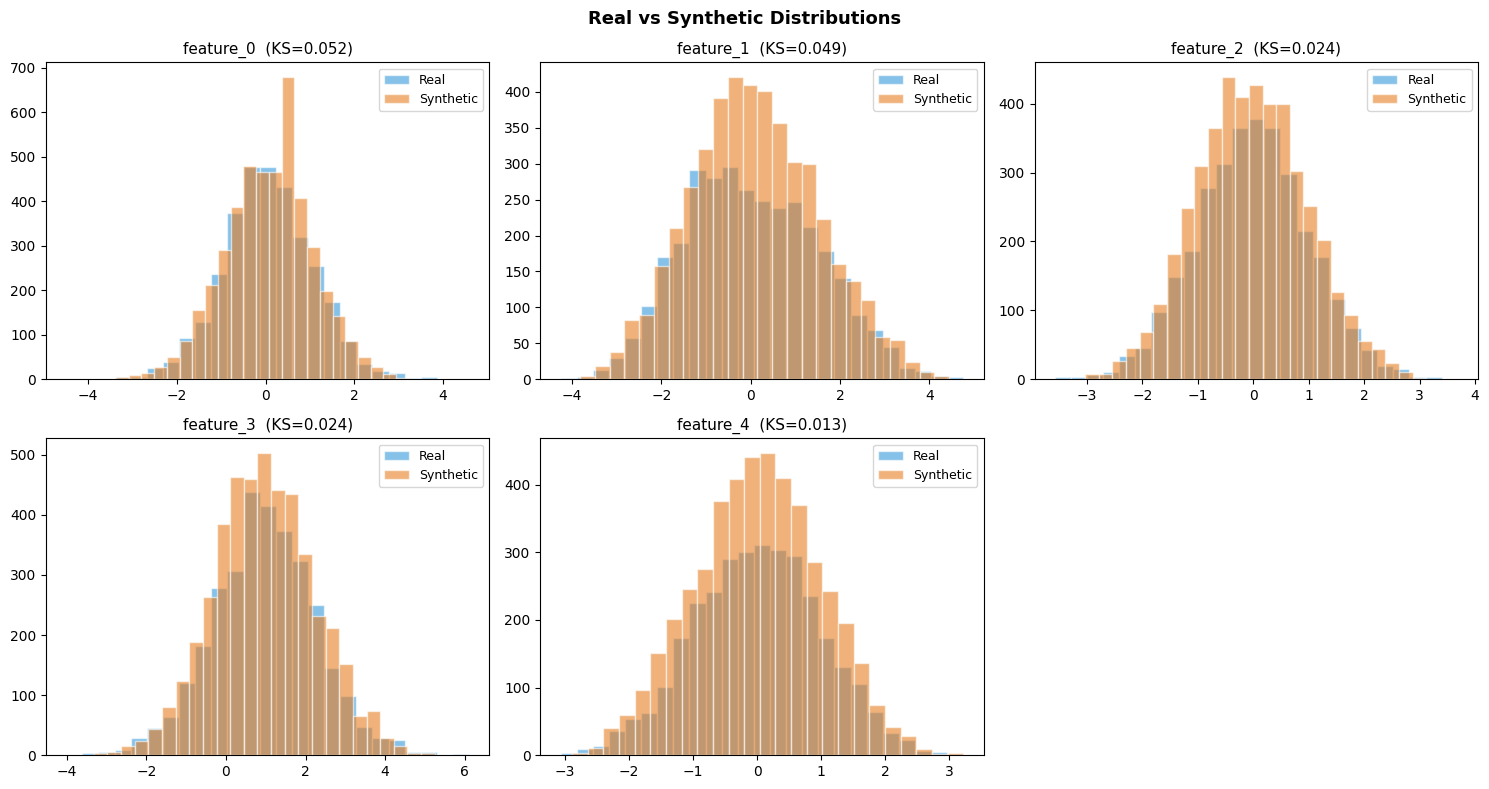

In [7]:
# --- Distribution comparison plots ---
num_cols = train_full.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c in synthetic_df.columns and c != target_col_name][:5]

if num_cols:
    fig, axes = plt.subplots(int(np.ceil(len(num_cols)/3)), 3, figsize=(15, 8))
    if type(axes) == np.ndarray: axes = axes.flatten()
    else: axes = [axes]

    for i, col in enumerate(num_cols):
        real_vals = train_full[col].dropna()
        synt_vals = synthetic_df[col].dropna()
        ks = quality_report['per_column'].get(col, {}).get('ks_stat', np.nan)

        axes[i].hist(real_vals, bins=25, alpha=0.60, color='#3498db', label='Real', edgecolor='white')
        axes[i].hist(synt_vals, bins=25, alpha=0.60, color='#e67e22', label='Synthetic', edgecolor='white')
        axes[i].set_title(f'{col}  (KS={ks:.3f})', fontsize=11)
        axes[i].legend(fontsize=9)

    for j in range(len(num_cols), len(axes)):
        axes[j].axis('off')
        
    plt.suptitle('Real vs Synthetic Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('artifacts/synthetic_quality_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

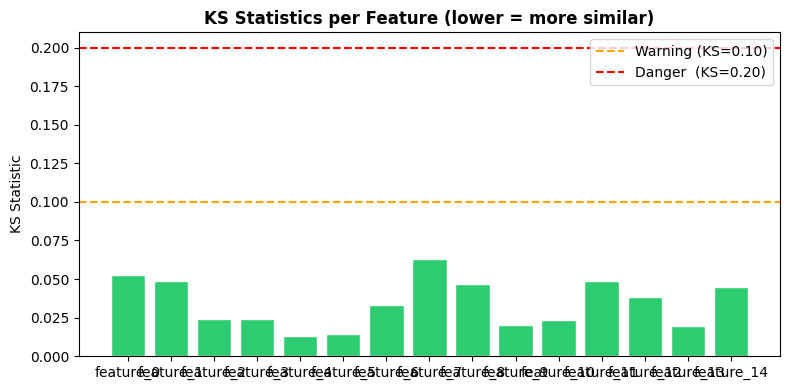

In [8]:
# KS statistic bar chart
ks_data = {col: vals['ks_stat'] for col, vals in quality_report['per_column'].items()}
plt.figure(figsize=(8, 4))
colors = ['#e74c3c' if v > 0.2 else '#f39c12' if v > 0.1 else '#2ecc71' for v in ks_data.values()]
plt.bar(ks_data.keys(), ks_data.values(), color=colors, edgecolor='white')
plt.axhline(0.1, color='orange', linestyle='--', label='Warning (KS=0.10)')
plt.axhline(0.2, color='red',    linestyle='--', label='Danger  (KS=0.20)')
plt.title('KS Statistics per Feature (lower = more similar)', fontweight='bold')
plt.ylabel('KS Statistic')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/synthetic_ks_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Artefacts

In [9]:
import os
os.makedirs('artifacts', exist_ok=True)

# Save raw synthetic samples
synthetic_df.to_csv('artifacts/synthetic_samples.csv', index=False)
print(f'synthetic_samples.csv saved  ({len(synthetic_df)} rows)')

# Save the global generator
save_generator(generator, 'artifacts/sdv_copula_model.pkl')

# Save quality report
import json
with open('artifacts/synthetic_quality_report.json', 'w') as f:
    json.dump(quality_report, f, indent=2)
print('synthetic_quality_report.json saved')

print(f'\n=== Quality Summary ===')
print(f'  Mean KS stat : {quality_report["overall_ks_mean"]}')
print(f'  Max  KS stat : {quality_report["overall_ks_max"]}')

synthetic_samples.csv saved  (4550 rows)
[generator_utils] Synthesizer saved -> artifacts/sdv_copula_model.pkl
synthetic_quality_report.json saved

=== Quality Summary ===
  Mean KS stat : 0.0344
  Max  KS stat : 0.0628
